## Data Cleaning & Preprocessing

Load the Data: The dataset is read from a CSV file.

Handle Missing Values: Some columns had missing entries (like Product ID, Source, etc.), and you filled them with default values.

Drop Unnecessary Columns: You removed columns that are not useful for prediction, such as Created, Product_ID, and Status.

Label Encoding: Since machine learning models can't directly handle text, all text-based columns like Source, Mobile, Email, etc., were converted into numbers.

## Feature Preparation 
   
Split Data: The data is divided into input features (X) and the target column Delivery_Mode (Y).

Train-Test Split: The dataset is split into 70% training and 30% test data.

Scaling: Feature values are standardized to bring them to the same scale, which helps many machine learning models perform better.

3. Model Training
A Random Forest Classifier (a tree-based model) is trained using the training data.

The trained model is then used to predict the delivery mode on the test data.



Model Evaluation The model's performance is measured using:

Accuracy: How many predictions were correct.

F1 Score (macro, micro, weighted): Balances precision and recall, especially helpful for imbalanced data.

 Model Saving
The trained model is saved into a .pkl file (using pickle), so it can be used later without retraining.

## Data Visualization
You plot:

Class Distribution: Shows how balanced the target classes are.

Correlation Heatmap: Shows how features are related to each other and to the target.

Pair Plot: Visual comparison of top features and how they relate to the target.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [46]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score
import pickle


In [47]:
df = pd.read_csv("new_data.csv")


In [48]:
df.head()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
0,14-11-2018 10:05,NaN,Website,984XXXXXXX,aXXXXXXX@gmail.com,Sales-Agent-11,NaN,Mode-5,Open
1,14-11-2018 09:22,NaN,Website,XXXXXXX,#VALUE!,Sales-Agent-10,NaN,Mode-5,Open
2,14-11-2018 09:21,NaN,Website,XXXXXXX,dXXXXXXX@yahoo.com,Sales-Agent-10,NaN,Mode-5,Open
3,14-11-2018 08:46,NaN,Website,XXXXXXX,wXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open
4,14-11-2018 07:34,NaN,Website,XXXXXXX,cXXXXXXX@gmail.com,Sales-Agent-10,NaN,Mode-5,Open


In [49]:
df.tail()

,Created,Product_ID,Source,Mobile,EMAIL,Sales_Agent,Location,Delivery_Mode,Status
7417,28-04-2018 09:45,9.0,Call,NaN,aXXXXXXX@gmail.com,Sales-Agent-6,Mumbai,Mode-4,LOST
7418,28-04-2018 09:43,15.0,Call,NaN,#VALUE!,Sales-Agent-12,Other Locations,Mode-5,LOST
7419,28-04-2018 09:20,5.0,Live Chat-Direct,NaN,sXXXXXXX@gmail.com,Sales-Agent-11,Bangalore,Mode-1,Not Responding
7420,28-04-2018 08:04,21.0,CRM form,NaN,YXXXXXXX@gmail.com,Sales-Agent-4,Other Locations,Mode-1,Just Enquiry
7421,28-04-2018 07:54,25.0,Website,NaN,cXXXXXXX@gmail.com,Sales-Agent-3,Chennai,Mode-1,CONVERTED


In [50]:
df.columns

Index(['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent',
       'Location', 'Delivery_Mode', 'Status'],
      dtype='object')

In [51]:
df.shape

(7422, 9)

In [52]:
df.size

66798

In [53]:
# Fill missing values
df['Source'].fillna("Call", inplace=True)
df['Mobile'].fillna("222", inplace=True)
df['Sales_Agent'].fillna("1550", inplace=True)
df['Location'].fillna("2500", inplace=True)

C:\Users\prath\AppData\Local\Temp\ipykernel_19940\1795304601.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Source'].fillna("Call", inplace=True)
C:\Users\prath\AppData\Local\Temp\ipykernel_19940\1795304601.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [54]:
print("Columns:", df.columns.tolist())


Columns: ['Created', 'Product_ID', 'Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location', 'Delivery_Mode', 'Status']


In [55]:
# Drop columns if they exist
cols_to_drop = ['product_id', 'status', 'Created']
df.drop(cols_to_drop, axis=1, inplace=True, errors='ignore')

In [56]:
categorical_cols = ['Source', 'Mobile', 'EMAIL', 'Sales_Agent', 'Location', 'Delivery_Mode']
for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])

In [57]:
X = df.drop('Delivery_Mode', axis=1)
y = df['Delivery_Mode']

In [58]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [59]:
print(X_train.dtypes)


Product_ID     float64
Source           int32
Mobile           int32
EMAIL            int32
Sales_Agent      int32
Location         int32
Status          object
dtype: object


In [60]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.columns:
    if X_train[col].dtype == 'object':
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))


In [61]:
X_train = X_train.select_dtypes(exclude=['object'])
X_test = X_test.select_dtypes(exclude=['object'])


In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [63]:
# Train RandomForest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [64]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

In [65]:
print("\nRandomForest Model Performance:")
print(" Accuracy Score:", accuracy)
print(" F1 Score (Macro):", f1_macro)
print(" F1 Score (Micro):", f1_micro)
print(" F1 Score (Weighted):", f1_weighted)


RandomForest Model Performance:
 Accuracy Score: 0.7144140098787607
 F1 Score (Macro): 0.4502952076539696
 F1 Score (Micro): 0.7144140098787607
 F1 Score (Weighted): 0.7080681692242962


In [66]:
# Save the model
with open("lead_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [67]:
# Dataset info
print("\nDataset Info:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7422 entries, 0 to 7421
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Product_ID     7364 non-null   float64
 1   Source         7422 non-null   int32  
 2   Mobile         7422 non-null   int32  
 3   EMAIL          7422 non-null   int32  
 4   Sales_Agent    7422 non-null   int32  
 5   Location       7422 non-null   int32  
 6   Delivery_Mode  7422 non-null   int32  
 7   Status         7422 non-null   object 
dtypes: float64(1), int32(6), object(1)
memory usage: 290.1+ KB
None

Summary Statistics:
        Product_ID       Source       Mobile        EMAIL  Sales_Agent  \
count  7364.000000  7422.000000  7422.000000  7422.000000  7422.000000   
mean     15.947311    11.601994   308.554972   382.303153     6.975344   
std       6.072937     8.545591   149.658489   299.480150     2.874139   
min       0.000000     0.000000     0.000000     0.00

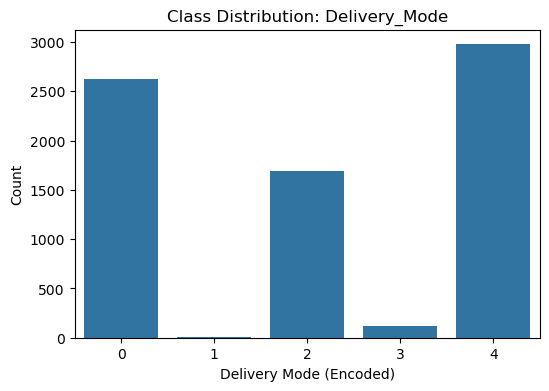

In [68]:
# Class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Delivery_Mode', data=df)
plt.title("Class Distribution: Delivery_Mode")
plt.xlabel("Delivery Mode (Encoded)")
plt.ylabel("Count")
plt.show()


In [69]:
numeric_df = df.select_dtypes(include=['number'])


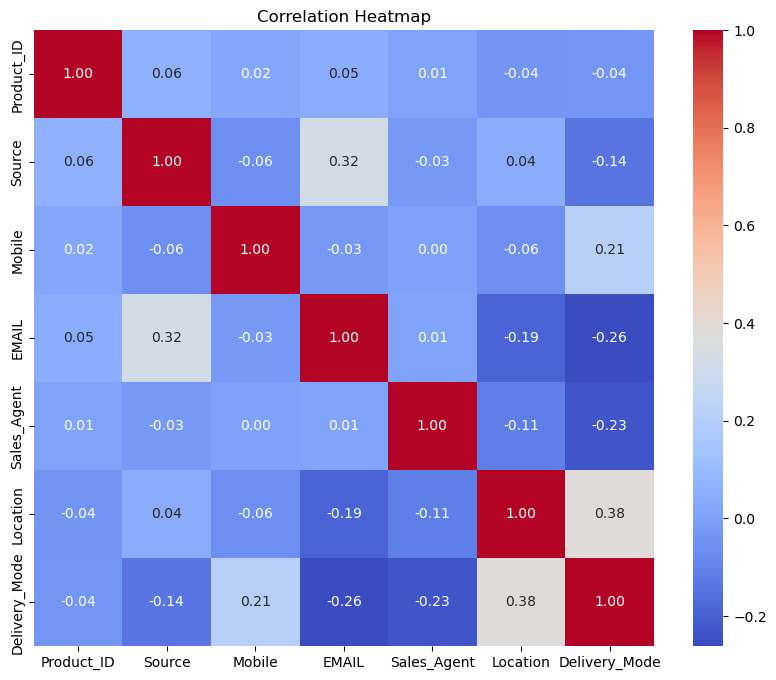

In [70]:
plt.figure(figsize=(10, 8))
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


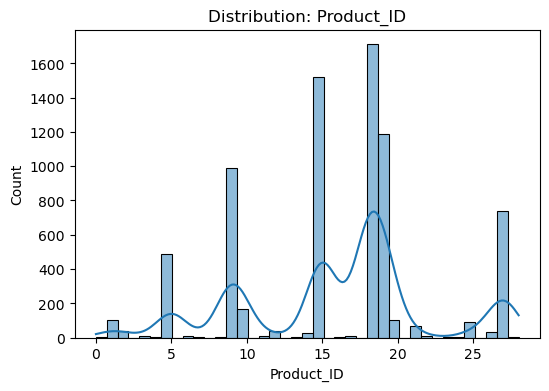

In [71]:
# Histograms of numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution: {col}")
    plt.show()


In [72]:
numeric_df = df.select_dtypes(include=['number'])


In [73]:
# top correlated features for Delivery_Mode
top_features = numeric_df.corr()['Delivery_Mode'].abs().sort_values(ascending=False)[1:5].index.tolist()


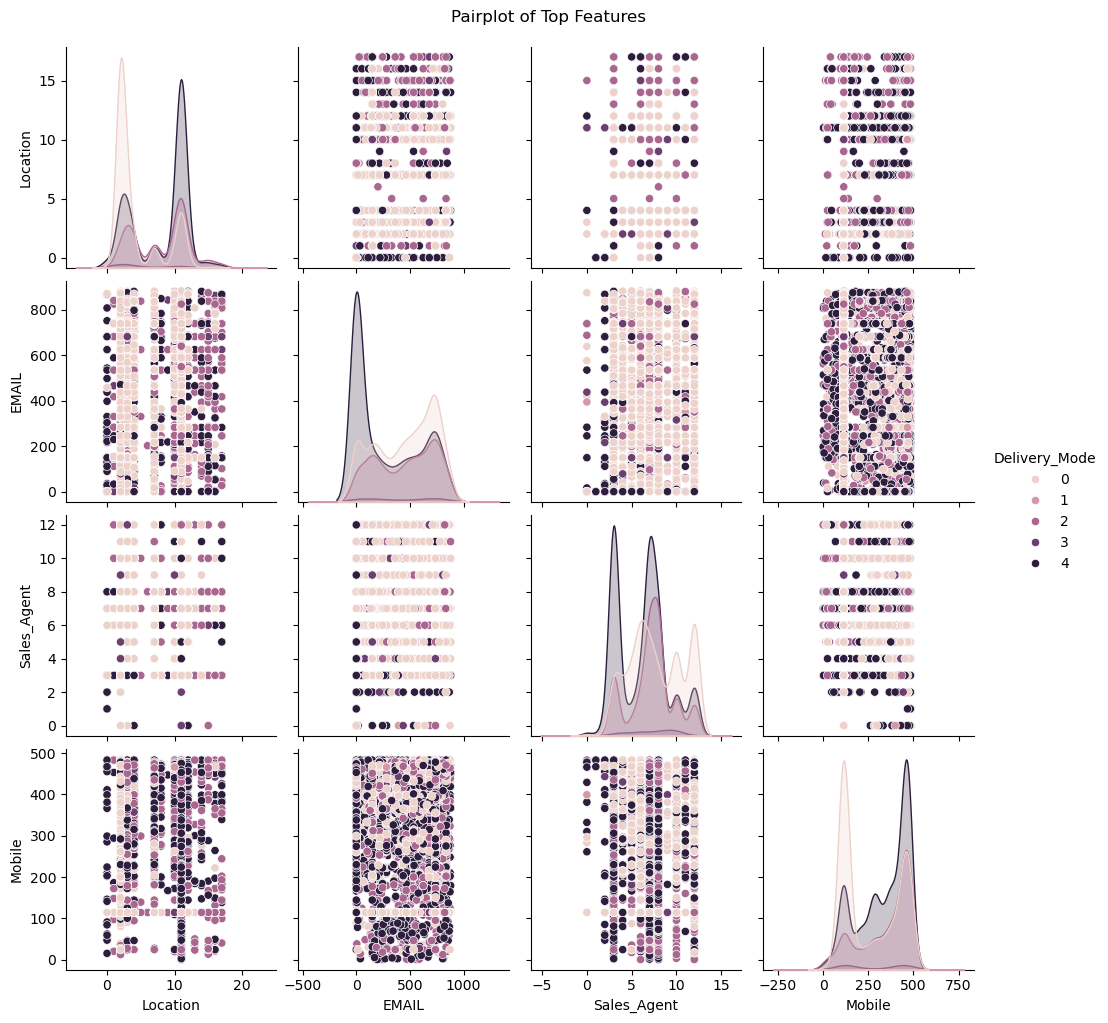

In [74]:
numeric_df = df.select_dtypes(include=['number'])

top_features = numeric_df.corr()['Delivery_Mode'].abs().sort_values(ascending=False)[1:5].index.tolist()

sns.pairplot(df[top_features + ['Delivery_Mode']], hue='Delivery_Mode')
plt.suptitle("Pairplot of Top Features", y=1.02)
plt.show()


In [75]:
# Model comparison
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

In [76]:
from sklearn.impute import SimpleImputer

# Impute NaN values with mean
imputer = SimpleImputer(strategy='mean')
X_train_scaled = imputer.fit_transform(X_train_scaled)
X_test_scaled = imputer.transform(X_test_scaled)

results = []
for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    results.append({
        'Model': name,
        'Accuracy': acc,
        'F1 Score': f1
    })
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.sort_values(by='F1 Score', ascending=False))


C:\Users\prath\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:183: UserWarning: [09:33:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model Comparison:
                 Model  Accuracy  F1 Score
2        Random Forest  0.713516  0.706517
3              XGBoost  0.707678  0.702743
1        Decision Tree  0.623709  0.623098
0  Logistic Regression  0.573866  0.544544


In [77]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [78]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1
)


In [79]:
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_

print("\nBest Parameters from GridSearch:", grid_search.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters from GridSearch: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


In [80]:
# Evaluate best model
y_pred_best = best_model.predict(X_test_scaled)
accuracy_best = accuracy_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best, average='weighted')

In [81]:
print(" Best Model Accuracy:", accuracy_best)
print(" Best Model F1 Score:", f1_best)

 Best Model Accuracy: 0.7256398742703188
 Best Model F1 Score: 0.715805205880246


## Model Comparison
You tested four different machine learning models:

Logistic Regression

Decision Tree

Random Forest

XGBoost

Each model's accuracy and F1 Score are calculated and compared.

This helps you choose the best-performing model.

Hyperparameter Tuning
You use GridSearchCV to automatically test different settings for the Random Forest model.

It chooses the best combination of parameters (like number of trees, max depth, etc.) to improve performance.

The best model is evaluated again for accuracy and F1 score.

Final Output
Best model performance is printed.

Best model parameters are shown.

Model is ready to be used for predicting delivery mode on new lead data.